In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score

In [2]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

In [3]:
df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

# Convert to binary classification
df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (125973, 44)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,binary_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [4]:
X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (100778, 41)
Test Shape: (25195, 41)


In [5]:
preprocessor = joblib.load("models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)

Processed Train Shape: (100778, 121)


In [6]:
baseline_model = LogisticRegression(max_iter=500)

baseline_model.fit(X_train_processed, y_train)

y_pred_baseline = baseline_model.predict(X_test_processed)

print("Baseline Model Performance")
print(classification_report(y_test, y_pred_baseline))

Baseline Model Performance
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
# Quick check to verify that feature importance values remain stable across different random seeds

rf_alt = RandomForestClassifier(random_state=0)
rf_alt.fit(X_train_processed, y_train)

importance_difference = np.abs(
    rf.feature_importances_ - rf_alt.feature_importances_
)

print("Average importance difference between runs:",
      importance_difference.mean())

Average importance difference between runs: 0.002617662863200394


In [9]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(15)

,feature,importance
2,num__dst_bytes,0.139586
1,num__src_bytes,0.116439
119,cat__flag_SF,0.066402
29,num__dst_host_srv_count,0.059725
26,num__diff_srv_rate,0.055968
25,num__same_srv_rate,0.041918
31,num__dst_host_diff_srv_rate,0.039592
30,num__dst_host_same_srv_rate,0.034392
22,num__srv_serror_rate,0.031850
115,cat__flag_S0,0.030221


In [10]:
importance_df['feature'] = (
    importance_df['feature']
    .str.replace('num__','', regex=False)
    .str.replace('cat__','', regex=False)
)

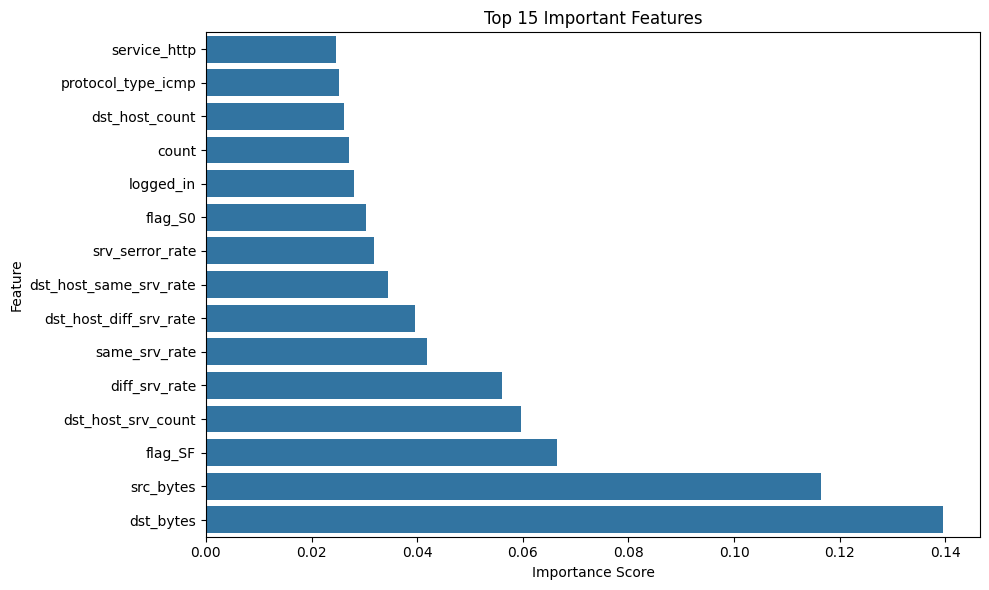

In [11]:
top_features = importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=top_features
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Top features such as `dst_host_serror_rate`, `src_bytes`, and `count`
capture abnormal network traffic patterns that are often associated
with intrusion attempts. These attributes help the model distinguish
between normal and malicious behavior.

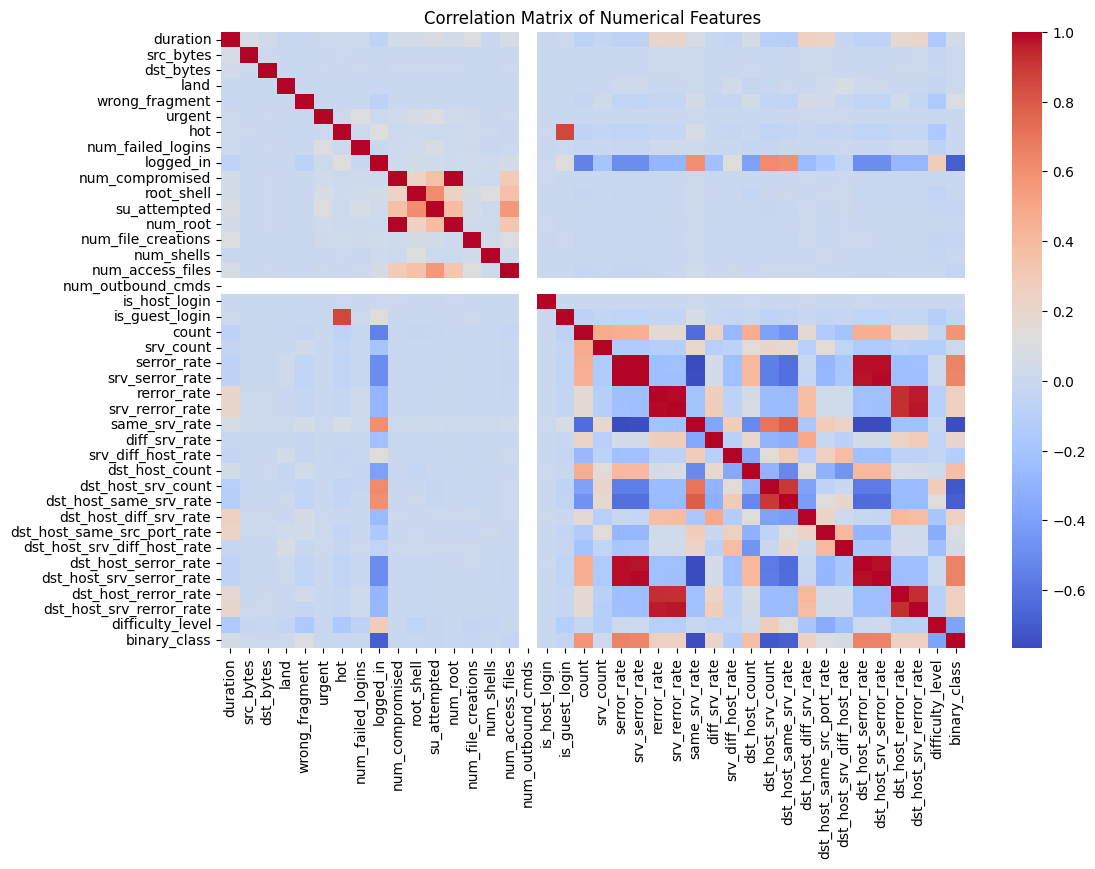

In [12]:
# Correlation analysis of numerical features
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

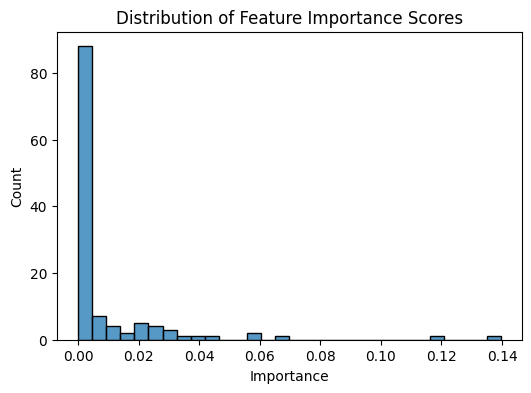

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(importance_df['importance'], bins=30)
plt.title("Distribution of Feature Importance Scores")
plt.xlabel("Importance")
plt.ylabel("Count")
plt.show()

In [14]:
top_n = 20

selected_features = importance_df.head(top_n)['feature']

mask = importance_df['feature'].isin(selected_features)

selected_indices = np.where(mask)[0]

X_train_topn = X_train_processed[:, selected_indices]
X_test_topn = X_test_processed[:, selected_indices]

print("Original Feature Count:", X_train_processed.shape[1])
print("Reduced Feature Count:", X_train_topn.shape[1])

Original Feature Count: 121
Reduced Feature Count: 20


In [15]:

threshold = 0.01

selected_threshold = importance_df[
    importance_df['importance'] > threshold
]['feature']

print("Features selected using threshold:", len(selected_threshold))

Features selected using threshold: 25


In [16]:
model_full = LogisticRegression(max_iter=500)

model_full.fit(X_train_processed, y_train)

y_pred_full = model_full.predict(X_test_processed)

print("Performance Using All Features")
print(classification_report(y_test, y_pred_full))

Performance Using All Features
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



In [17]:
model_selected = LogisticRegression(max_iter=500)

model_selected.fit(X_train_topn, y_train)

y_pred_selected = model_selected.predict(X_test_topn)

print("Performance Using Selected Features")
print(classification_report(y_test, y_pred_selected))

Performance Using Selected Features
              precision    recall  f1-score   support

           0       0.87      0.79      0.83     13469
           1       0.78      0.86      0.82     11726

    accuracy                           0.82     25195
   macro avg       0.82      0.82      0.82     25195
weighted avg       0.83      0.82      0.82     25195



In [18]:
acc_full = accuracy_score(y_test, y_pred_full)
acc_selected = accuracy_score(y_test, y_pred_selected)

print("Accuracy (All Features):", acc_full)
print("Accuracy (Selected Features):", acc_selected)

Accuracy (All Features): 0.9718991863464973
Accuracy (Selected Features): 0.8218297281206589


In [19]:
print("Recall (All Features):",
      recall_score(y_test, y_pred_full))

print("Recall (Selected Features):",
      recall_score(y_test, y_pred_selected))

Recall (All Features): 0.9629029507078287
Recall (Selected Features): 0.858775370970493


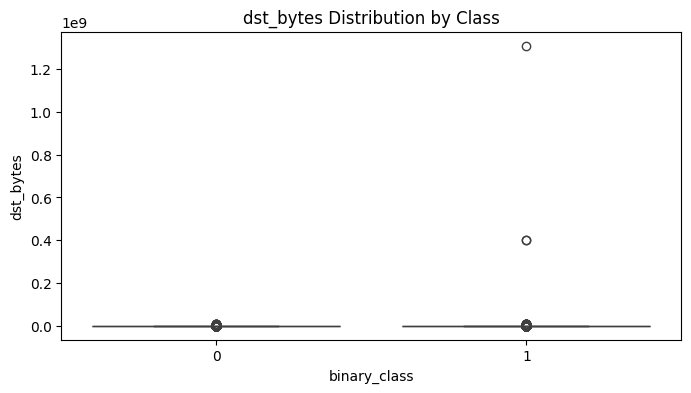

In [20]:
most_important_feature = importance_df.iloc[0]['feature']

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['binary_class'],
    y=df[most_important_feature]
)

plt.title(f"{most_important_feature} Distribution by Class")

plt.show()